In [3]:
!kaggle competitions download -c drw-crypto-market-prediction

import zipfile
import os

with zipfile.ZipFile('drw-crypto-market-prediction.zip', 'r') as zip_ref:
    zip_ref.extractall('../data')
os.remove('drw-crypto-market-prediction.zip')


  0%|          | 0.00/6.30G [00:00<?, ?B/s]
  0%|          | 2.00M/6.30G [00:00<05:27, 20.6MB/s]
  0%|          | 6.00M/6.30G [00:00<03:43, 30.3MB/s]
  0%|          | 11.0M/6.30G [00:00<03:01, 37.2MB/s]
  0%|          | 16.0M/6.30G [00:00<02:44, 41.0MB/s]
  0%|          | 22.0M/6.30G [00:00<02:28, 45.5MB/s]
  0%|          | 27.0M/6.30G [00:00<02:32, 44.0MB/s]
  0%|          | 32.0M/6.30G [00:00<02:40, 42.0MB/s]
  1%|          | 37.0M/6.30G [00:00<02:30, 44.6MB/s]
  1%|          | 42.0M/6.30G [00:01<02:25, 46.1MB/s]
  1%|          | 47.0M/6.30G [00:01<02:25, 46.2MB/s]
  1%|          | 53.0M/6.30G [00:01<02:15, 49.6MB/s]
  1%|          | 59.0M/6.30G [00:01<02:07, 52.7MB/s]
  1%|          | 65.0M/6.30G [00:01<02:36, 42.8MB/s]
  1%|          | 70.0M/6.30G [00:01<02:30, 44.5MB/s]
  1%|          | 76.0M/6.30G [00:01<02:25, 46.0MB/s]
  1%|▏         | 82.0M/6.30G [00:01<02:21, 47.2MB/s]
  1%|▏         | 87.0M/6.30G [00:02<02:19, 47.8MB/s]
  1%|▏         | 92.0M/6.30G [00:02<02:17, 48.3MB/s]
 

drw-crypto-market-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
train_df = pd.read_parquet('../data/train.parquet')
train_df.head()

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X882,X883,X884,X885,X886,X887,X888,X889,X890,label
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-03-01 00:00:00,15.283,8.425,176.405,44.984,221.389,0.121263,-0.417690,0.005399,0.125948,0.058359,...,1.925423,1.847943,0.005676,0.190791,0.369691,0.377630,0.210153,0.159183,0.530636,0.562539
2023-03-01 00:01:00,38.590,2.336,525.846,321.950,847.796,0.302841,-0.049576,0.356667,0.481087,0.237954,...,1.928569,1.849468,0.005227,0.184660,0.363642,0.374515,0.209573,0.158963,0.530269,0.533686
2023-03-01 00:02:00,0.442,60.250,159.227,136.369,295.596,0.167462,-0.291212,0.083138,0.206881,0.101727,...,1.928047,1.849282,0.004796,0.178719,0.357689,0.371424,0.208993,0.158744,0.529901,0.546505
2023-03-01 00:03:00,4.865,21.016,335.742,124.963,460.705,0.072944,-0.436590,-0.102483,0.017551,0.007149,...,1.928621,1.849608,0.004398,0.172967,0.351832,0.368358,0.208416,0.158524,0.529534,0.357703
2023-03-01 00:04:00,27.158,3.451,98.411,44.407,142.818,0.173820,-0.213489,0.096067,0.215709,0.107133,...,1.927084,1.848950,0.004008,0.167391,0.346066,0.365314,0.207839,0.158304,0.529167,0.362452


In [2]:
test_df = pd.read_parquet('../data/test.parquet')
test_df.head()
test_df = test_df.reset_index()

In [6]:
print(train_df.columns)
train_df = train_df.reset_index()
train_df['timestamp']

Index(['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume', 'X1', 'X2', 'X3',
       'X4', 'X5',
       ...
       'X882', 'X883', 'X884', 'X885', 'X886', 'X887', 'X888', 'X889', 'X890',
       'label'],
      dtype='object', length=896)


0        2023-03-01 00:00:00
1        2023-03-01 00:01:00
2        2023-03-01 00:02:00
3        2023-03-01 00:03:00
4        2023-03-01 00:04:00
                 ...        
525882   2024-02-29 23:55:00
525883   2024-02-29 23:56:00
525884   2024-02-29 23:57:00
525885   2024-02-29 23:58:00
525886   2024-02-29 23:59:00
Name: timestamp, Length: 525887, dtype: datetime64[ns]

In [3]:
print(test_df.columns)
test_df['ID']

Index(['ID', 'bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume', 'X1', 'X2',
       'X3', 'X4',
       ...
       'X882', 'X883', 'X884', 'X885', 'X886', 'X887', 'X888', 'X889', 'X890',
       'label'],
      dtype='object', length=897)


0              1
1              2
2              3
3              4
4              5
           ...  
538145    538146
538146    538147
538147    538148
538148    538149
538149    538150
Name: ID, Length: 538150, dtype: int64

In [24]:
missing = train_df.isnull().sum()
print(missing[missing>0])

Series([], dtype: int64)


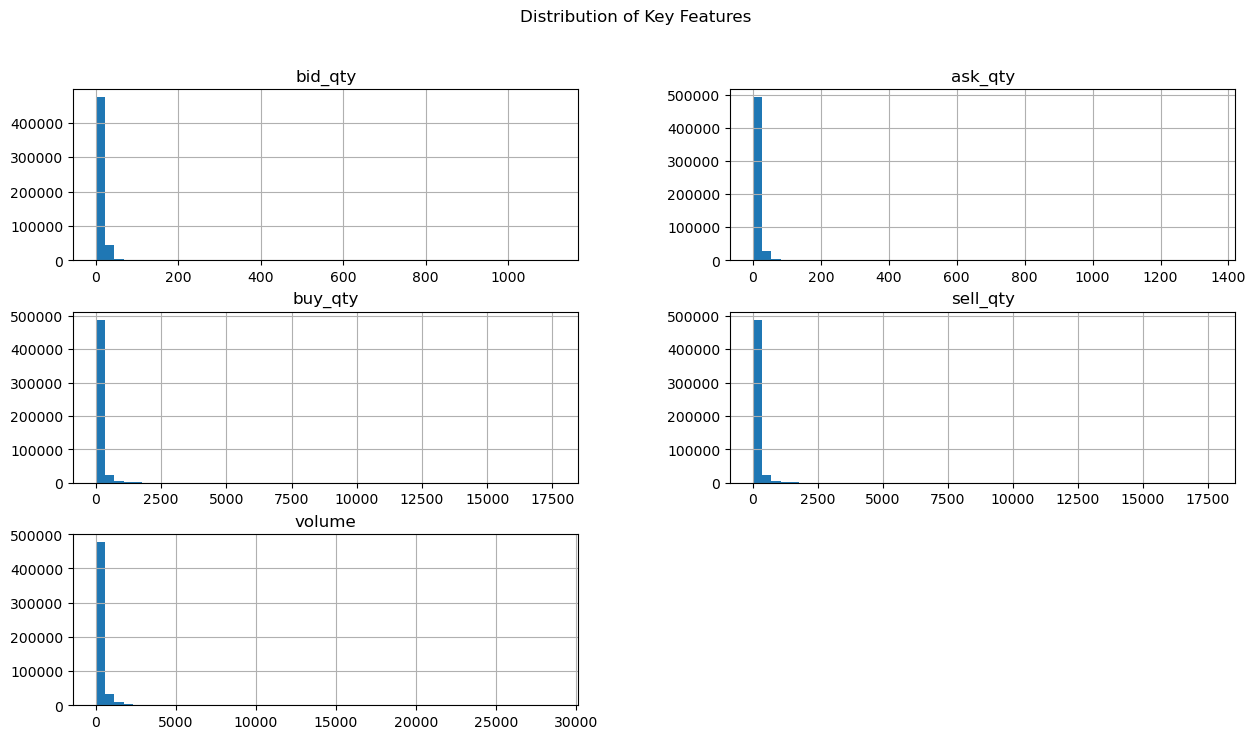

In [10]:
DistKey = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
train_df[DistKey].hist(bins=50, figsize=(15,8))
plt.suptitle('Distribution of Key Features')

plt.show()

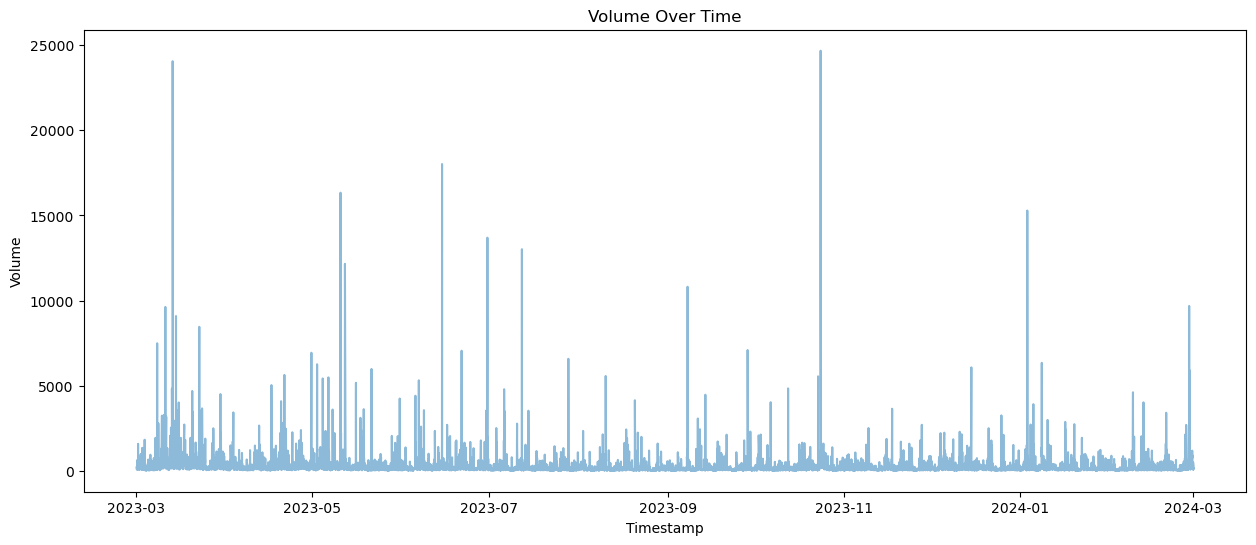

In [22]:
sample_df = train_df.sample(10000).sort_values('timestamp')

plt.figure(figsize=(15,6))
plt.plot(sample_df['timestamp'], sample_df['volume'], alpha=0.5)
plt.title('Volume Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Volume')
plt.show()


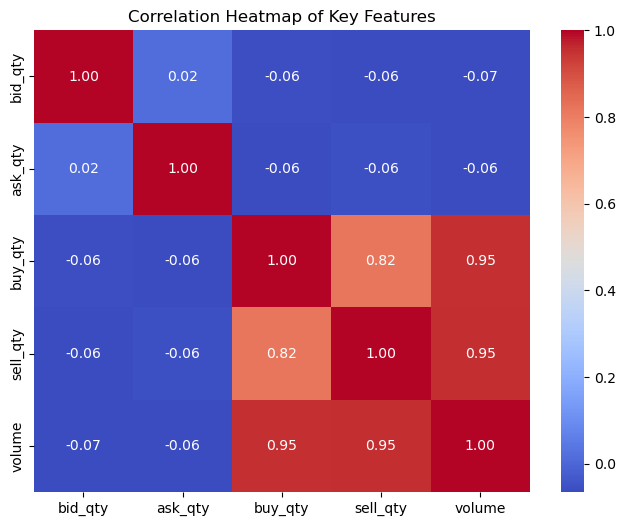

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(train_df[DistKey].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Features')
plt.show()

In [28]:
correlation = train_df[DistKey + ['label']].corr()['label'].sort_values(ascending=False)
print(correlation)

label       1.000000
sell_qty    0.011166
volume      0.008809
buy_qty     0.005618
bid_qty    -0.013220
ask_qty    -0.015762
Name: label, dtype: float64


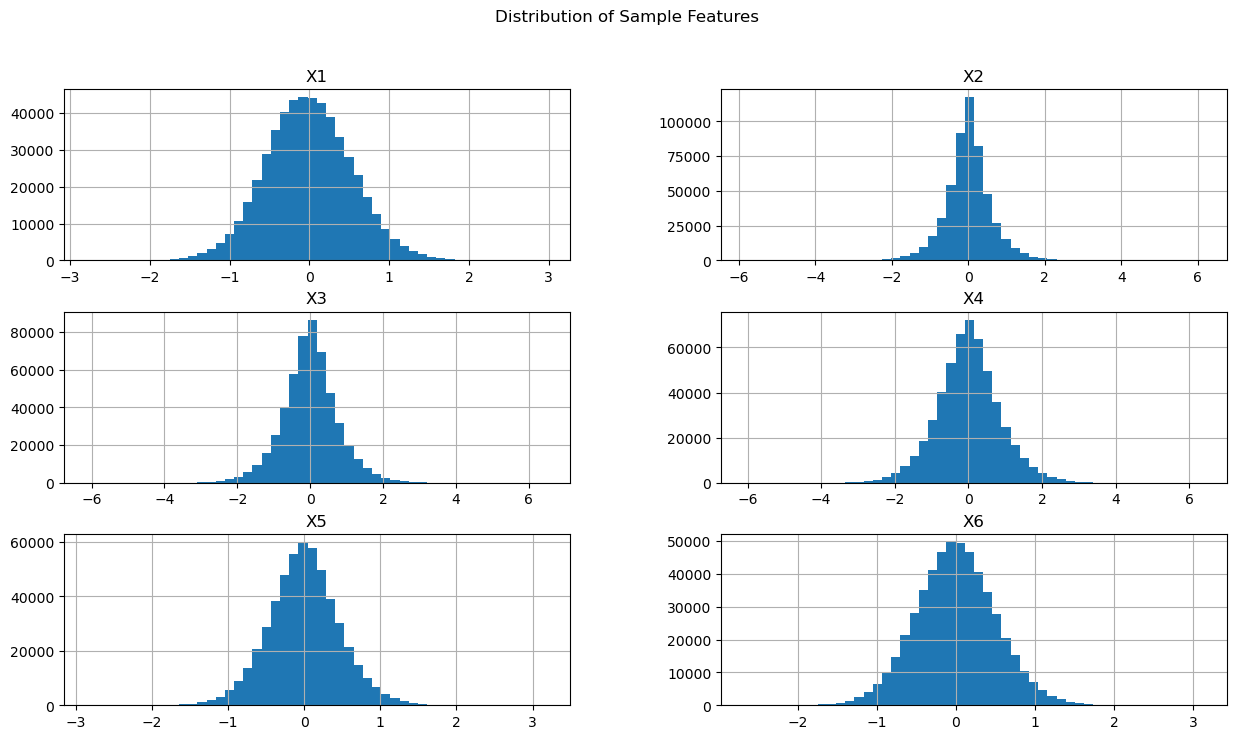

In [38]:
sample_feature = train_df.columns[8:898][:6]
train_df[sample_feature].hist(bins=50, figsize=(15,8))
plt.suptitle('Distribution of Sample Features')
plt.show()

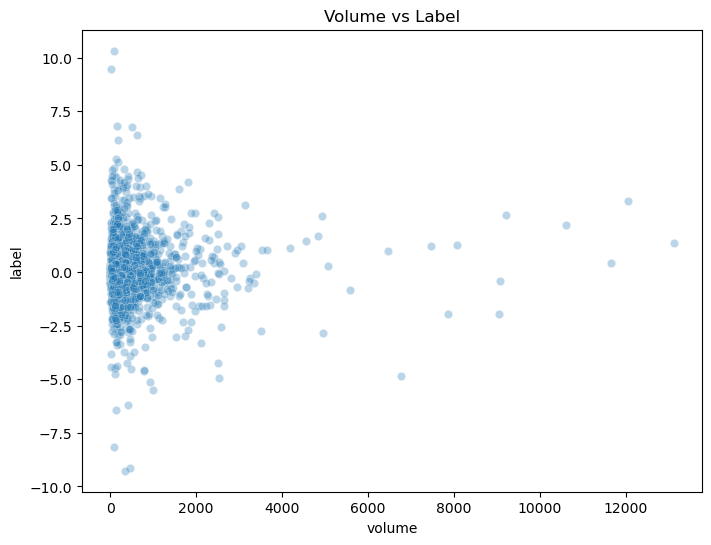

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='volume', y='label', data=train_df.sample(5000), alpha=0.3)
plt.title("Volume vs Label")
plt.show()


In [12]:
cols_to_transform = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
for col in cols_to_transform:
    train_df[col] = np.log1p(train_df[col])


In [19]:
train_df[cols_to_transform].skew()

bid_qty    -0.045680
ask_qty    -0.055558
buy_qty     0.196580
sell_qty    0.185919
volume      0.346301
dtype: float64

In [7]:
test_col_to_transform = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
for col in test_col_to_transform:
    test_df[col] = np.log1p(test_df[col])
test_df[test_col_to_transform].skew()

bid_qty     0.061467
ask_qty     0.058458
buy_qty     0.214921
sell_qty    0.212720
volume      0.303505
dtype: float64

In [20]:
train_df[cols_to_transform].kurtosis()


bid_qty    -0.344758
ask_qty    -0.354773
buy_qty     0.240320
sell_qty    0.262368
volume      0.408073
dtype: float64

In [8]:
test_df[test_col_to_transform].kurtosis()

bid_qty    -0.332393
ask_qty    -0.302748
buy_qty     0.036091
sell_qty    0.085596
volume      0.127750
dtype: float64

In [22]:
train_df.to_parquet('../data/cleanedTrain.parquet')

In [9]:
test_df.to_parquet('../data/cleanedTest.parquet')